# What Data Augmentation is
Data augmentation means:
- Create modified versions of your training images to artificially increase the dataset size.
- Instead of giving the network only the original image, you also give slightly modified versions of it.

So instead of:
original image → CNN

We do:
original image,
flipped image,
cropped image,
brighter image,
 → CNN


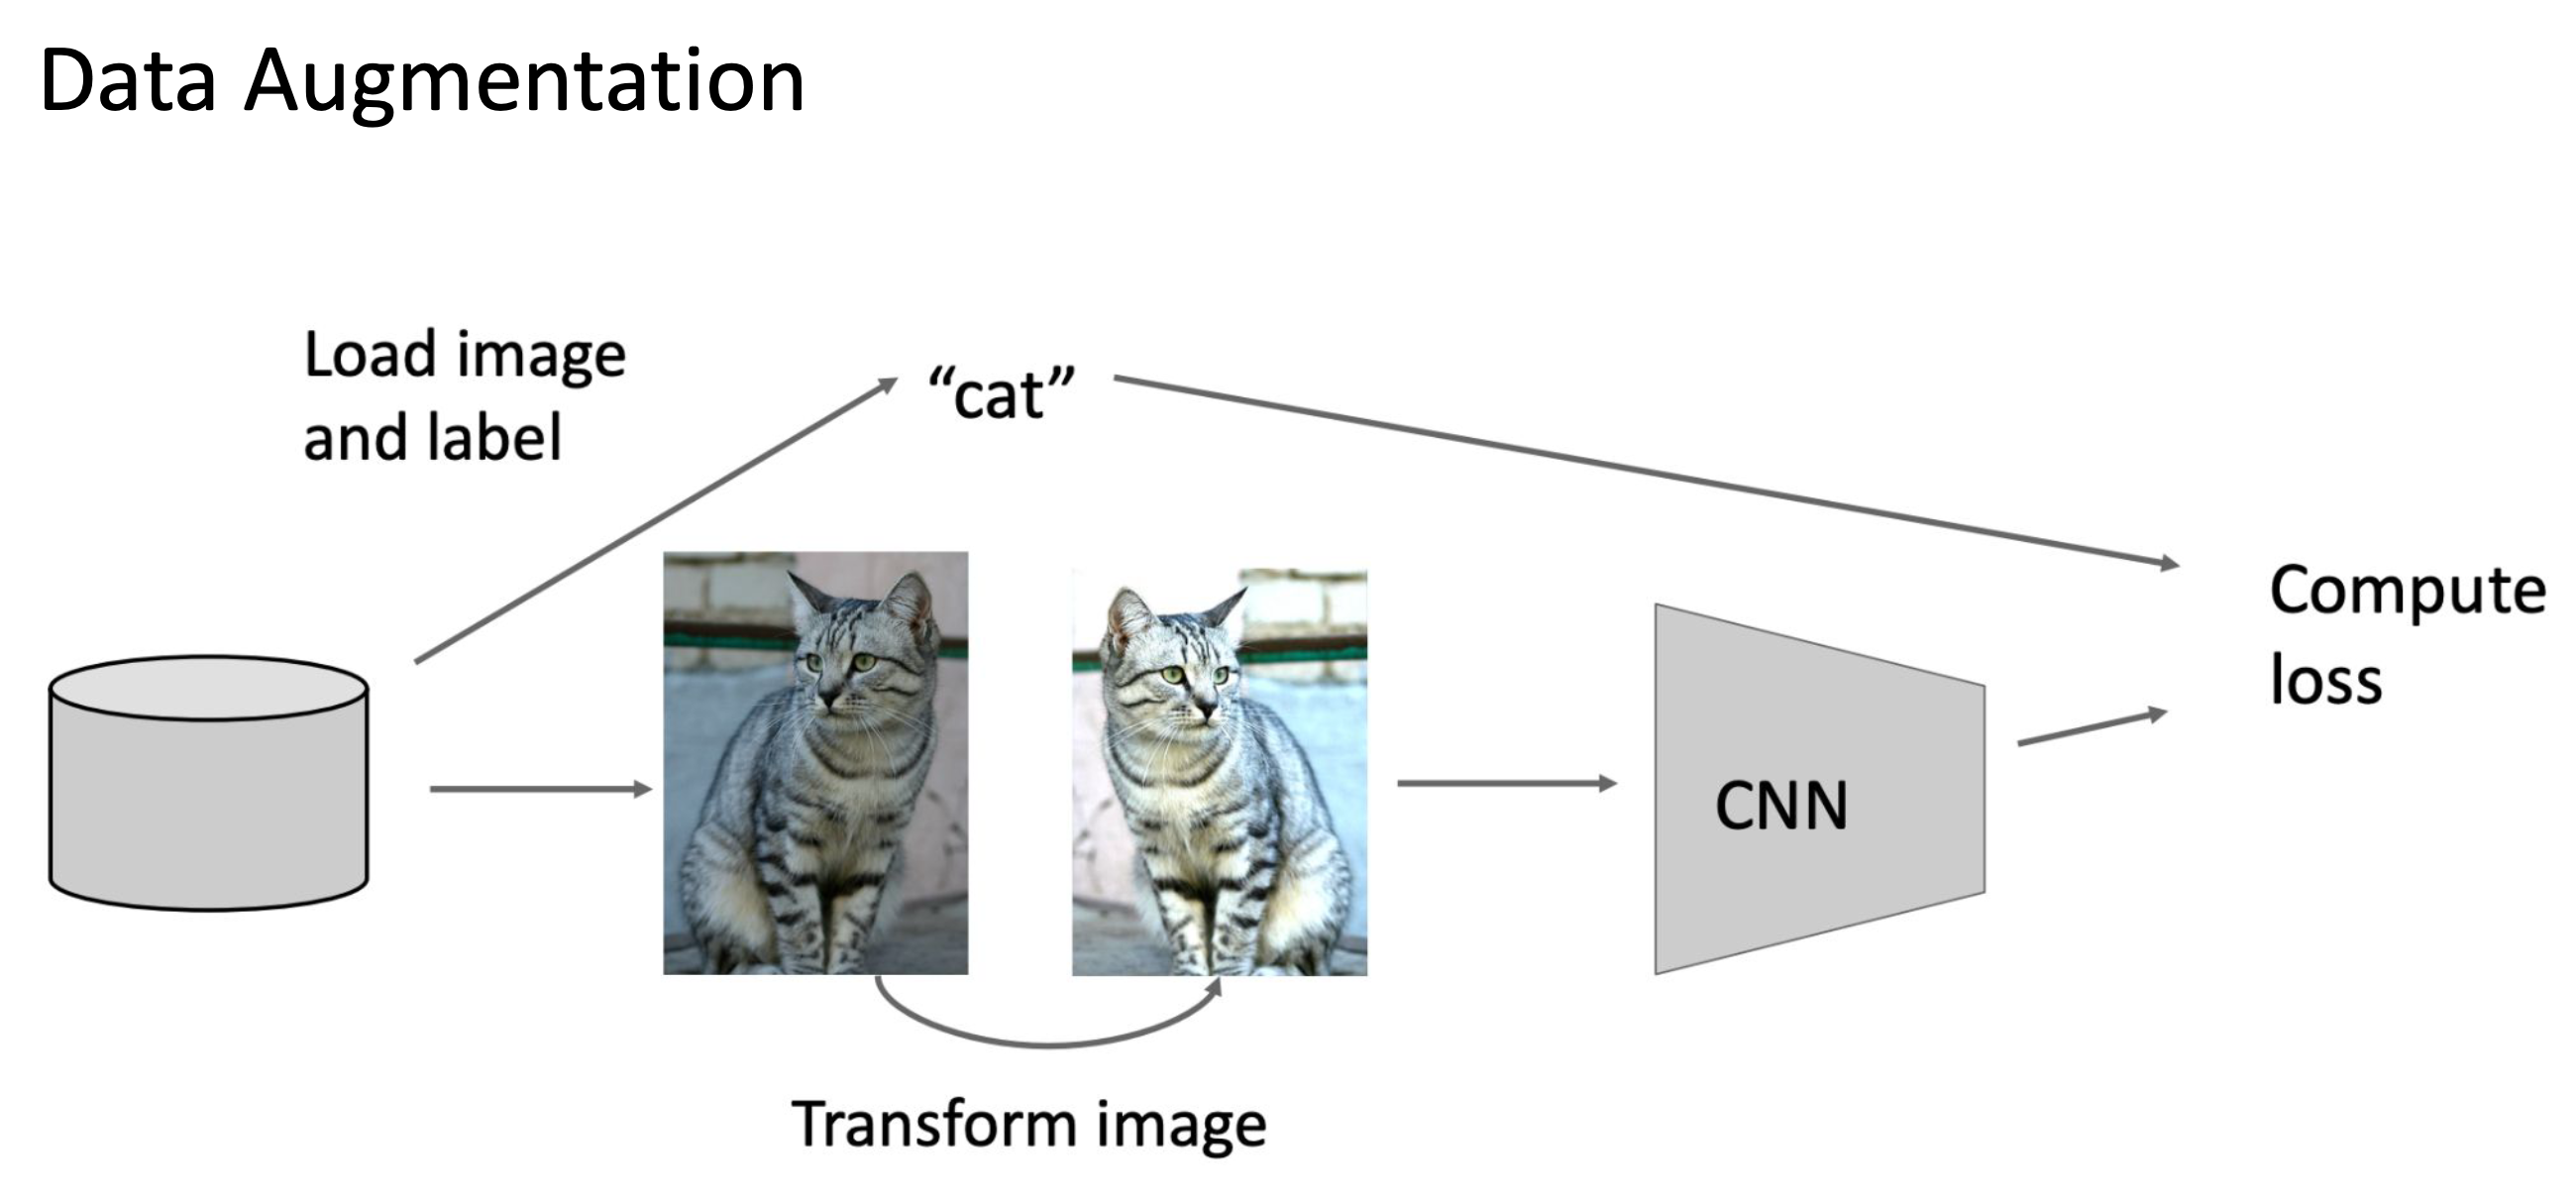


# Why we do Data Augmentation
Main reason: Reduce overfitting.  
- If a model always sees the exact same images, it can memorize them.
- Augmentation forces the model to learn general patterns instead.

A cat classifier should recognize a cat even if:
- the image is flipped
- the lighting changes
- the cat is slightly cropped
Augmentation teaches the model this robustness.

# Horizontal flip

In [ ]:
transforms.RandomHorizontalFlip(p=0.5)

- with 50% probability
- the image is flipped horizontally.

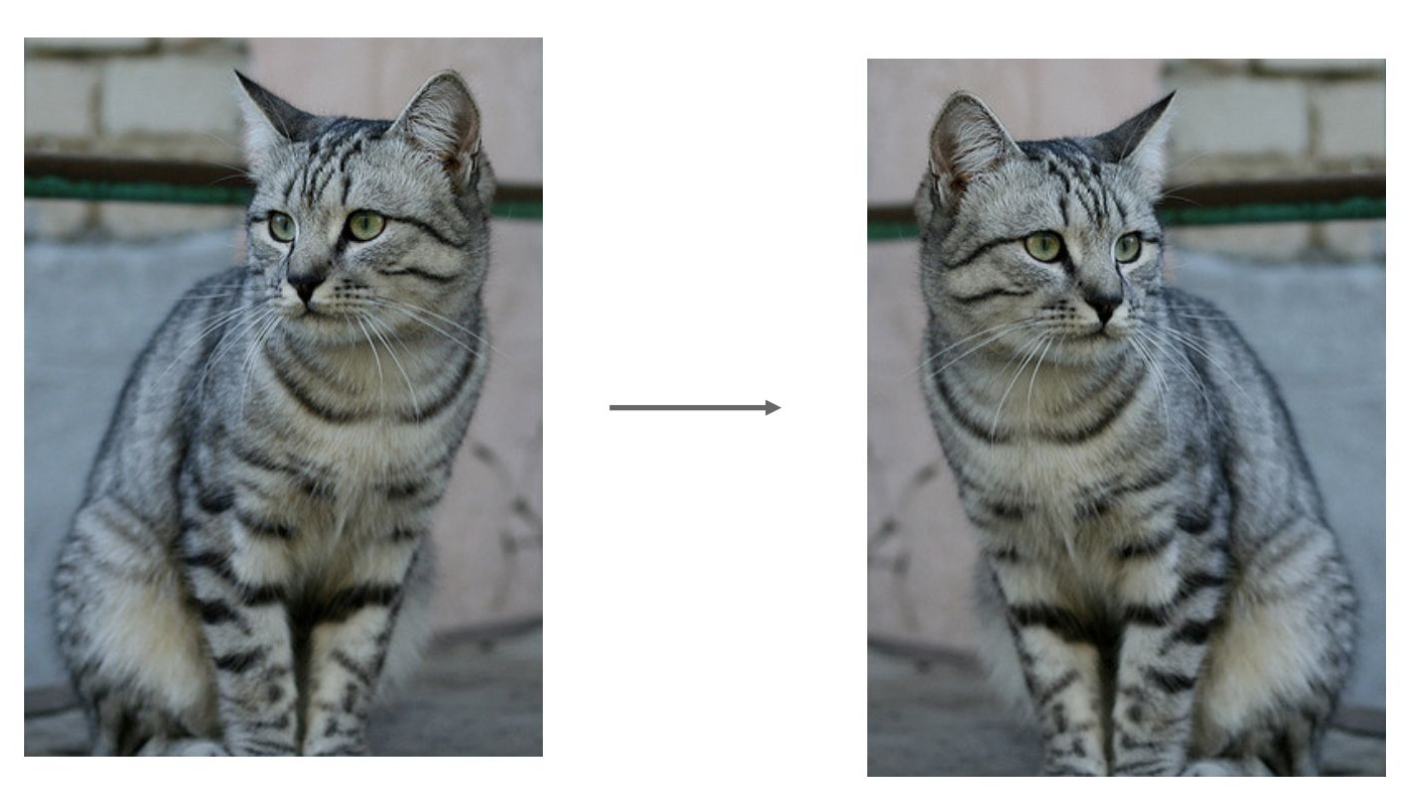

# Random Crops and Scales
Instead of always feeding the same full image:  
1.	resize image  
2.	randomly crop a patch  

So the pipeline:
original image  
        ↓  
resize  
        ↓  
random crop (224x224)

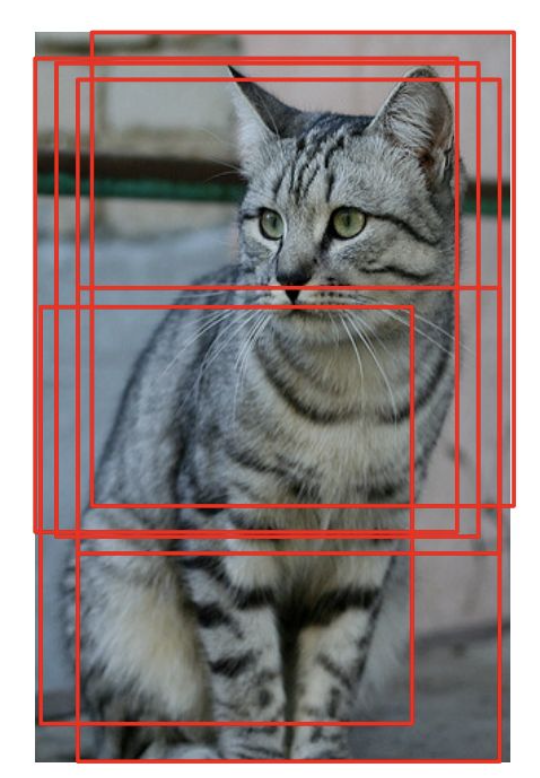

In [ ]:
torchvision.transforms.RandomCrop(size, padding=None,
                                     pad_if_needed=False,
                                     fill=0, padding_mode='constant')
torchvision.transforms.RandomResizedCrop(size, scale=(0.08, 1.0),
                                        ratio=(0.75, 1.3333333333333333),
                                        interpolation=2)

# Color Jitter
- Random brightness
- Random contrast
- Random color

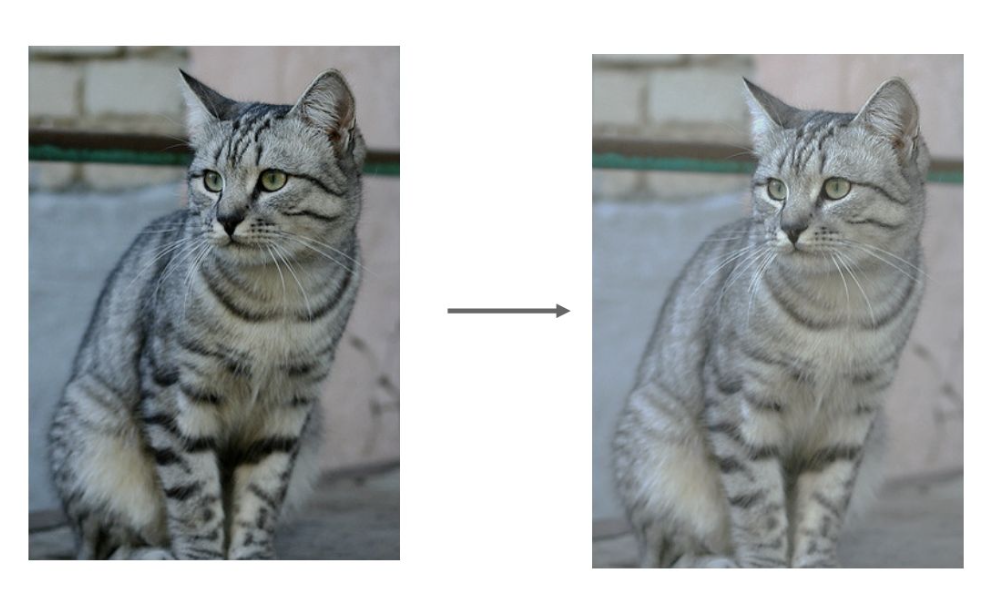

In [ ]:
torchvision.transforms.ColorJitter(brightness=0, contrast=0, saturation=0, hue=0)

---

In [ ]:
data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(...)
    ]),

    "val": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(...)
    ])
}

# Important
> Training: Random transformations --> because we want variety.  

> Validation: No randomness: --> because evaluation must be consistent.

**Note**: Augmentation happens inside the Dataset transformation pipeline, before the DataLoader gives the batch.

---

# ACTUAL LAB
1. Load the dataset and create a DataLoader for that.  
2. How many classes does it contain?  
3. How many samples?  
4. Visualize one example for class for 10 of its classes.  


We are already given this code:

In [3]:
# Import necessary libraries
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import requests
from zipfile import ZipFile
from io import BytesIO
import numpy as np

# Define the path to the dataset
dataset_path = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'  # Replace with the path to your dataset

# Send a GET request to the URL
response = requests.get(dataset_path)
# Check if the request was successful
if response.status_code == 200:
    # Open the downloaded bytes and extract them
    with ZipFile(BytesIO(response.content)) as zip_file:
        zip_file.extractall('dataset')
    print('Download and extraction complete!')

Download and extraction complete!


Internet (TinyImageNet.zip)  
        ↓  
download file  
        ↓  
open zip in memory  
        ↓  
extract files  
        ↓  
save dataset in /dataset  

> What the hell did I just download?  
- Tiny ImageNet is an image classification dataset.
- Given an image, predict which object category it belongs to.
    - dog
    - cat
	- bicycle
	- keyboard
	- mushroom
	- teapot
	- etc.

- Every class has 500 training images.
- Images are RGB (3 channels).

The structure is:  
```text
tiny-imagenet-200/  
│  
├── train/  
│   ├── class_1/  
│   │   └── images/  
│   │       ├── image_0.JPEG  
│   │       ├── image_1.JPEG  
│   │       └── ...  
│   │  
│   ├── class_2/  
│   │   └── images/  
│   │       ├── image_0.JPEG  
│   │       ├── image_1.JPEG  
│   │       └── ...  
│   │  
│   └── ...  
│  
├── val/  
│   ├── images/  
│   │   ├── val_0.JPEG  
│   │   ├── val_1.JPEG  
│   │   └── ...  
│   │  
│   └── val_annotations.txt  
│  
├── test/  
│   └── images/  
│       ├── test_0.JPEG  
│       ├── test_1.JPEG  
│       └── ...  
│  
├── wnids.txt  
└── words.txt  
```

- train folder
    - each folder corresponds to one class

- val folder
    - labels are stored in the file: val_annotations.txt

- test folder
    - test set has no labels

- wnids.txt file
    - Contains the 200 class IDs.

- words.txt file
    - Maps class IDs to human-readable names.



> **GOAL**: Load the TinyImageNet dataset, apply basic preprocessing transforms, create a DataLoader, and inspect the data.  

---

> # Pytorch VS torchvision
**1. Pytorch**  
Core deep-learning framework:  
- tensors
- autograd (gradients / .backward())
- neural network modules (torch.nn)
- optimizers (torch.optim)
- GPU / device management
- training loops


**2. torchvision**  
Torchvision is an add-on library for computer vision built on top of PyTorch.  
It provides tools specifically for image datasets and models.  

Main things it contains:  
1. Image datasets  
- Ready-to-use datasets.

2. Image transformations  

3. Pretrained models  

4. Utilities for images  

### So their reltionship is
``` text
PyTorch
│
├── tensors
├── autograd
├── neural networks
├── optimizers
│
└── torchvision
      ├── image datasets
      ├── image transforms
      ├── pretrained vision models
```

- PyTorch = general deep learning engine
- torchvision = computer vision toolkit built on PyTorch


> # import torchvision.transforms as transforms
- imports the module used to preprocess and augment images in PyTorch (torchvision).
- So its main role is image preprocessing before the data enters the neural network.

- torchvision.transforms includes two categories:
1. Preprocessing  
    - Resize  
    - ToTensor  
    - Normalize  
Used both in training and testing.  


2. Data augmentation  
    - RandomCrop  
    - RandomRotation  
    - RandomHorizontalFlip  
    - ColorJitter  
Used only during training to increase data variability --> obtain more robust models.  


| Transform | What it does | Category |
|---|---|---|
| `Resize` | Resizes the image to a fixed size (e.g. 64×64) | Preprocessing |
| `ToTensor()` | Converts a PIL image to a PyTorch tensor and rescales pixel values from `[0,255]` → `[0,1]` | Preprocessing |
| `Normalize()` | Normalizes pixel values using a mean and standard deviation (important for stable training) | Preprocessing |
| `RandomCrop` | Randomly selects a patch of the image and crops it | Data Augmentation |
| `RandomResizedCrop` | Randomly crops a region and resizes it to the desired size (introduces scale and translation variation) | Data Augmentation |
| `RandomHorizontalFlip` | Flips the image horizontally with a certain probability (e.g. 50%) | Data Augmentation |
| `ColorJitter` | Randomly changes brightness, contrast, saturation, and/or hue | Data Augmentation |
| `RandomRotation` | Rotates the image by a random angle | Data Augmentation |
| `RandomAffine` | Applies random affine transformations (rotation, scaling, translation, shear) | Data Augmentation |


And:
Image  
  ↓  
Preprocessing  
- Resize  
- ToTensor  
- Normalize  
  ↓  
Data Augmentation  
- RandomHorizontalFlip
- RandomCrop / RandomResizedCrop
- ColorJitter
- RandomRotation


> # .Compose()  
- It is used to build a pipeline
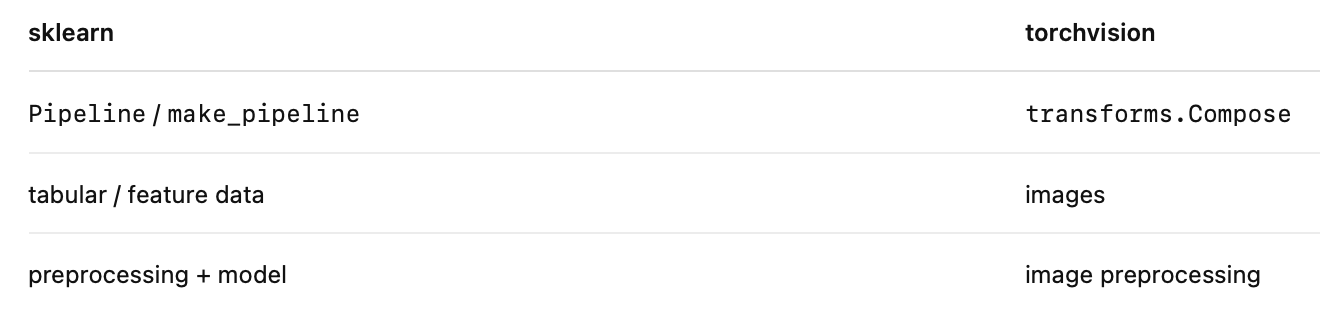

- Both used for:  
input  
 ↓  
step1  
 ↓  
step2  
 ↓  
step3  
 ↓  
output  

- **BUT** transforms.Compose handles pure preprocessing functions.
- **No** learning happens.
- Compose is much simpler.

> # ImageFolder()
- Ready-made Dataset class in torchvision that loads images from folders and automatically assigns labels based on the folder names
    - In short: **folder name = class label**
- So ImageFolder expects:
``` text
dataset/
│
├── class_1/
│   ├── img1.jpg
│   ├── img2.jpg
│   └── ...
│
├── class_2/
│   ├── img1.jpg
│   ├── img2.jpg
│   └── ...
```
> Where each folder corresponds to one class.

> Example:  
``` text
train/
   cat/
       cat1.jpg
       cat2.jpg
   dog/
       dog1.jpg
       dog2.jpg
``` text

- ImageFolder creates something like:
dataset[0] → (cat1.jpg, 0)  
dataset[1] → (cat2.jpg, 0)  
dataset[2] → (dog1.jpg, 1)  
dataset[3] → (dog2.jpg, 1)  

> # IMPORTANT, HERE YOU PASS THE TRANSFORMER
> tiny_imagenet_dataset_train = ImageFolder(root='dataset/tiny-imagenet-200/train', **transform=transform**)

In [6]:
# Define transformations for the dataset
    # Define how images should be converted and prepared before entering the neural network.
    # Raw images from disk are PIL images, but PyTorch models expect tensors.
    # So we define a transformation pipeline.

transform = transforms.Compose([
    transforms.ToTensor()   # Convert a PIL Image or ndarray to tensor and scale the values accordingly + in the range [0.0, 1.0]
])


# Load the dataset
tiny_imagenet_dataset_train = ImageFolder(root='dataset/tiny-imagenet-200/train', transform=transform)
# tiny_imagenet_dataset_test = ImageFolder(root='/dataset/tiny-imagenet-200/test', transform=transform)
# --> we cannot use ImageFolder for the test, either they made it on purpose (I hope) or these dudes are moron

# Create a DataLoader (use batch size 32, the dudes of the lab made this lab with their ass)
dataloader_train = DataLoader(dataset=tiny_imagenet_dataset_train, batch_size=32, shuffle=True)
# dataloader_test = DataLoader(dataset=tiny_imagenet_dataset_test, batch_size=32, shuffle=True)

# Determine the number of classes and samples
num_classes = len(tiny_imagenet_dataset_train.classes)
num_samples = len(tiny_imagenet_dataset_train)

print(f'Number of classes: {num_classes}')
print(f'Number of samples: {num_samples}')


Number of classes: 200
Number of samples: 100000


In [ ]:
# Function to denormalize image for visualization
def denormalize(image):
    image = image.to('cpu').numpy().transpose((1, 2, 0))    #.transpose = from [C, H, W] --> [H, W, C]
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * std + mean
    image = np.clip(image, 0, 1)
    return image

# Visualize one example for each class for 10 classes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
classes_sampled = []
found_classes = 0

for i, (inputs, classes) in enumerate(dataloader_train):
    # todo

plt.show()


- denormalize(image) --> talkes an input a tensor shape: [3, H, W]
- moves the tensor to a numpy array (matplotlib works with array)
- .transpose((1, 2, 0)) --> reshapes the matrix so that the second dimension becomes the first, the third the second the the first the third.
- Usually during the preprocessing we nomalise pixels:
    > image_norm = (image - mean) / std --> So pixel values are no longer in [0,1].

- Therefore to plot the pixels we need to de-normalise them, to undo normalization:
    > image = image * std + mean
    - this part would made sense if in the transformer I would actually normalise pixels, but I don't --> let's add normalisation I guess.

- image = np.clip(image, 0, 1), this makes sure the values are exactly in the range [0,1] and not slightly off.

> so use this transformer:

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# WORKFLOW
Step 1: define preprocessing
Tell PyTorch how to convert raw images into model-ready inputs.
transform = transforms.Compose([
    transforms.ToTensor()
])

Step 2: build a Dataset
Tell PyTorch where the images are and how to load one sample.
dataset = ImageFolder(root='dataset/tiny-imagenet-200/train', transform=transform)

Step 3: build a DataLoader
Tell PyTorch how to group samples into batches.
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

Step 4: 
...

In [7]:
# Define transformations for the dataset
    # Define how images should be converted and prepared before entering the neural network.
    # Raw images from disk are PIL images, but PyTorch models expect tensors.
    # So we define a transformation pipeline.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# Load the dataset
tiny_imagenet_dataset_train = ImageFolder(root='dataset/tiny-imagenet-200/train', transform=transform)
# tiny_imagenet_dataset_test = ImageFolder(root='/dataset/tiny-imagenet-200/test', transform=transform)
# --> we cannot use ImageFolder for the test, either they made it on purpose (I hope) or these dudes are moron

# Create a DataLoader (use batch size 32, the dudes of the lab made this lab with their ass)
dataloader_train = DataLoader(dataset=tiny_imagenet_dataset_train, batch_size=32, shuffle=True)
# dataloader_test = DataLoader(dataset=tiny_imagenet_dataset_test, batch_size=32, shuffle=True)

# Determine the number of classes and samples
num_classes = len(tiny_imagenet_dataset_train.classes)
num_samples = len(tiny_imagenet_dataset_train)

print(f'Number of classes: {num_classes}')
print(f'Number of samples: {num_samples}')

Number of classes: 200
Number of samples: 100000


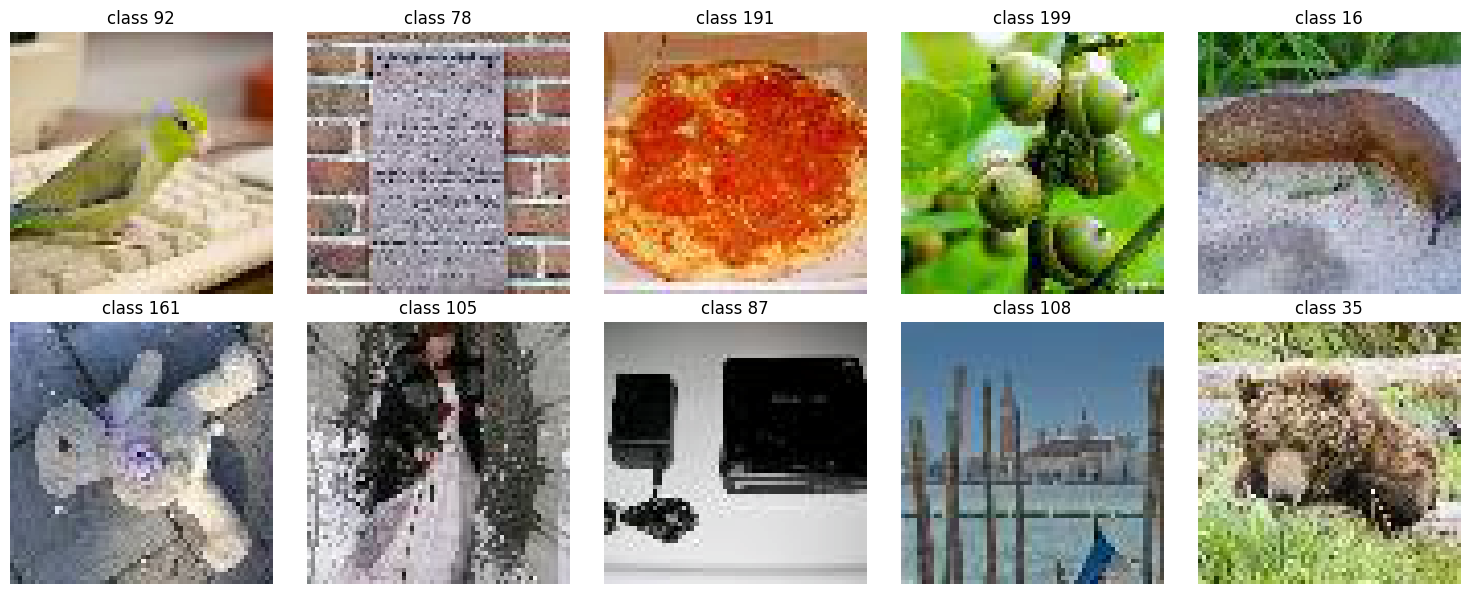

In [12]:
# Function to denormalize image for visualization
def denormalize(image):
    image = image.to('cpu').numpy().transpose((1, 2, 0))    #.transpose = from [C, H, W] --> [H, W, C]
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * std + mean
    image = np.clip(image, 0, 1)
    return image

# Visualize one example for each class for 10 classes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
classes_sampled = []
found_classes = 0

for inputs, classes in dataloader_train:
    # print(inputs, inputs.shape) --> [32, 3, 64, 64] = 32 images
    # print(classes, classes.shape) --> [32] = 32 labels
    batch_size = inputs.shape[0]

    for i in range(batch_size):
        label = classes[i].item()

        # if we haven't shown this class yet --> select the corresponding image, visualise it: denormalize it + flatten it + plt.imshow()
        if label not in classes_sampled:

            img = denormalize(inputs[i])

            ax = axes.flatten()[found_classes]
            ax.imshow(img)
            ax.set_title(f"class {label}")
            ax.axis("off")

            classes_sampled.append(label)
            found_classes += 1

        if found_classes == 10:
            break

    if found_classes == 10:
        break


plt.tight_layout()
plt.show()


- Dataloader gives batches:
    - 32 images
    - 32 labels
- Loop over batch
- Avoid duplicate classes
- Stop after 10
- Show figure